<a href="https://www.kaggle.com/code/adegbaju/dna-methylation-epigenetic-biomarkers-for-retina?scriptVersionId=327096296" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# DNA Methylation Epigenetic Biomarkers for Retinal Disease

 Early Detection and Risk Assessment – Industry‑Grade Machine Learning Pipeline

 **Dataset**: Synthetic CpG methylation data with binary target (methylated vs unmethylated).  
 **Goal**: Build, tune, interpret and export a production‑ready classification model.  
 **Files**: `train_data.csv`, `test_data.csv`



*DO NOT FORGET TO UPVOTE*

# Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

# Explainability
import shap

# Model persistence
import joblib
import pickle

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported.")


Libraries imported.


# Data Loading & Overview


In [2]:
# Load the training and test datasets
train_df = pd.read_csv("/kaggle/input/datasets/juanschafle/dna-methylation-data-epigenetic-biomarkers/train_data.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/juanschafle/dna-methylation-data-epigenetic-biomarkers/test_data.csv")

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (800, 5)
Test set shape: (200, 5)


In [3]:
train_df.head()

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
0,0.814178,0.289034,0.124878,0.886699,0
1,0.739617,0.348364,0.551552,0.682098,0
2,0.587255,0.642604,0.301904,1.000000,1
3,0.524876,0.856016,0.737112,0.613370,1
4,0.554851,0.659592,0.411018,0.613699,0


In [4]:
# Check data types and missing values
train_df.info()
train_df.isnull().sum().sum()  # should be 0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cpg_density         800 non-null    float64
 1   genomic_location    800 non-null    float64
 2   regulatory_score    800 non-null    float64
 3   conservation_score  800 non-null    float64
 4   methylation_status  800 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 31.4 KB


np.int64(0)


Target distribution (training):
methylation_status
1    443
0    357
Name: count, dtype: int64


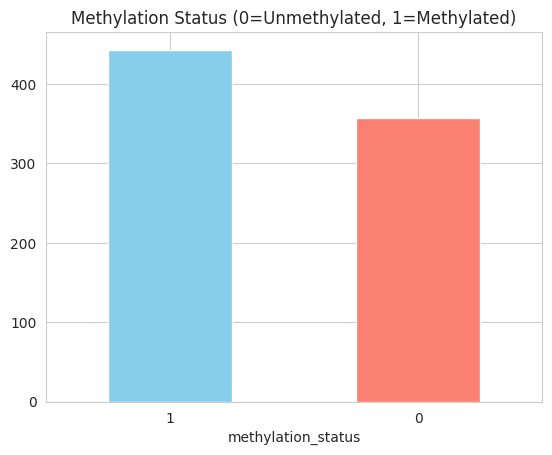

In [5]:
# Target distribution
target_counts = train_df['methylation_status'].value_counts()
print("\nTarget distribution (training):")
print(target_counts)
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Methylation Status (0=Unmethylated, 1=Methylated)")
plt.xticks(rotation=0)
plt.show()

#  Exploratory Data Analysis

In [6]:
# Separate features and target
X_train = train_df.drop('methylation_status', axis=1)
y_train = train_df['methylation_status']

X_test = test_df.drop('methylation_status', axis=1)
y_test = test_df['methylation_status']


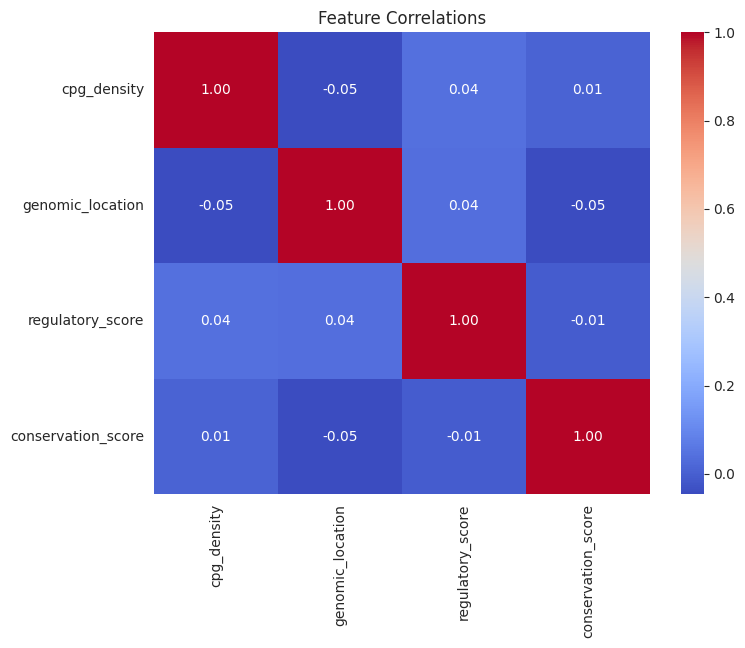

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlations")
plt.show()

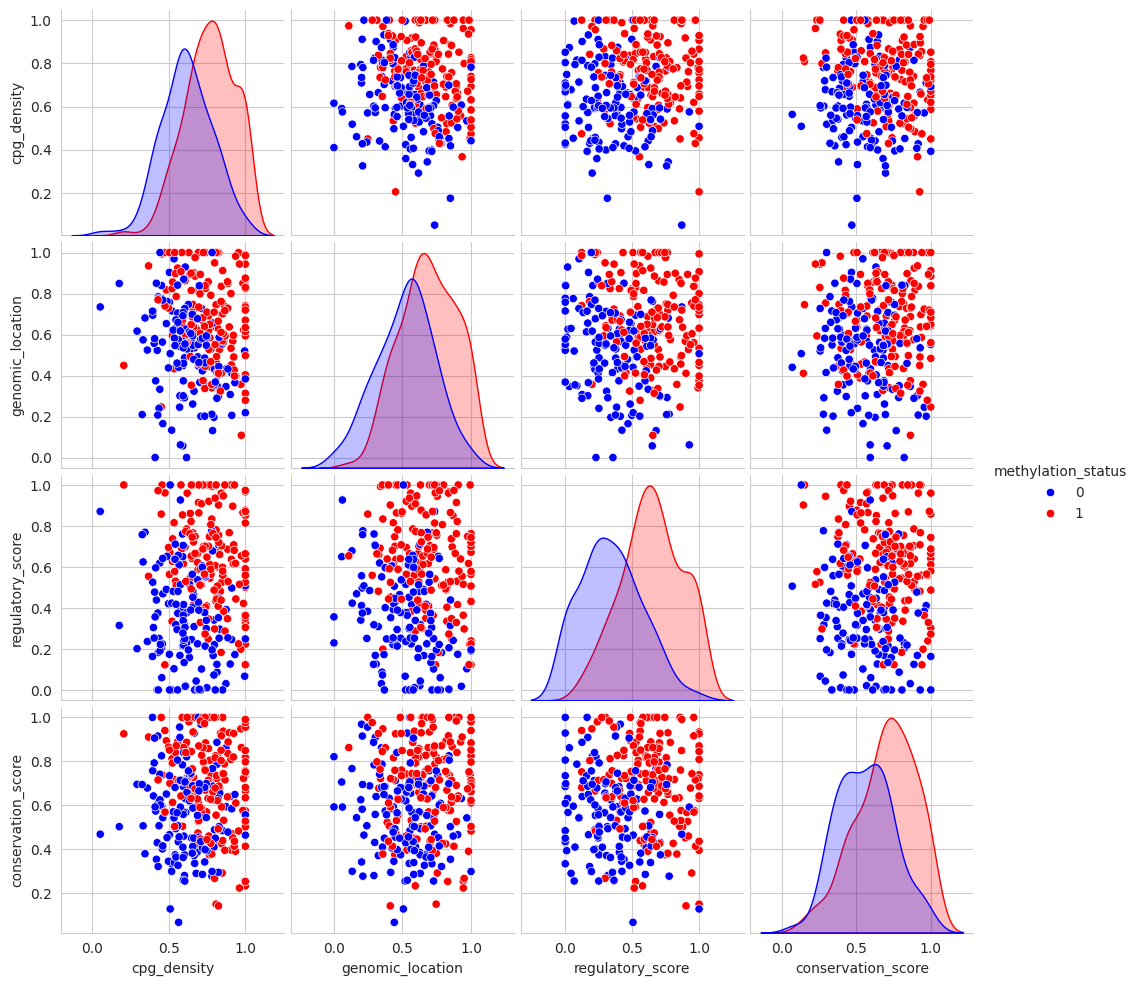

In [8]:
# Pairplot coloured by target (sample to avoid clutter)
sampled = train_df.sample(min(300, len(train_df)))
sns.pairplot(sampled, hue='methylation_status', diag_kind='kde', palette={0:'blue',1:'red'})
plt.show()

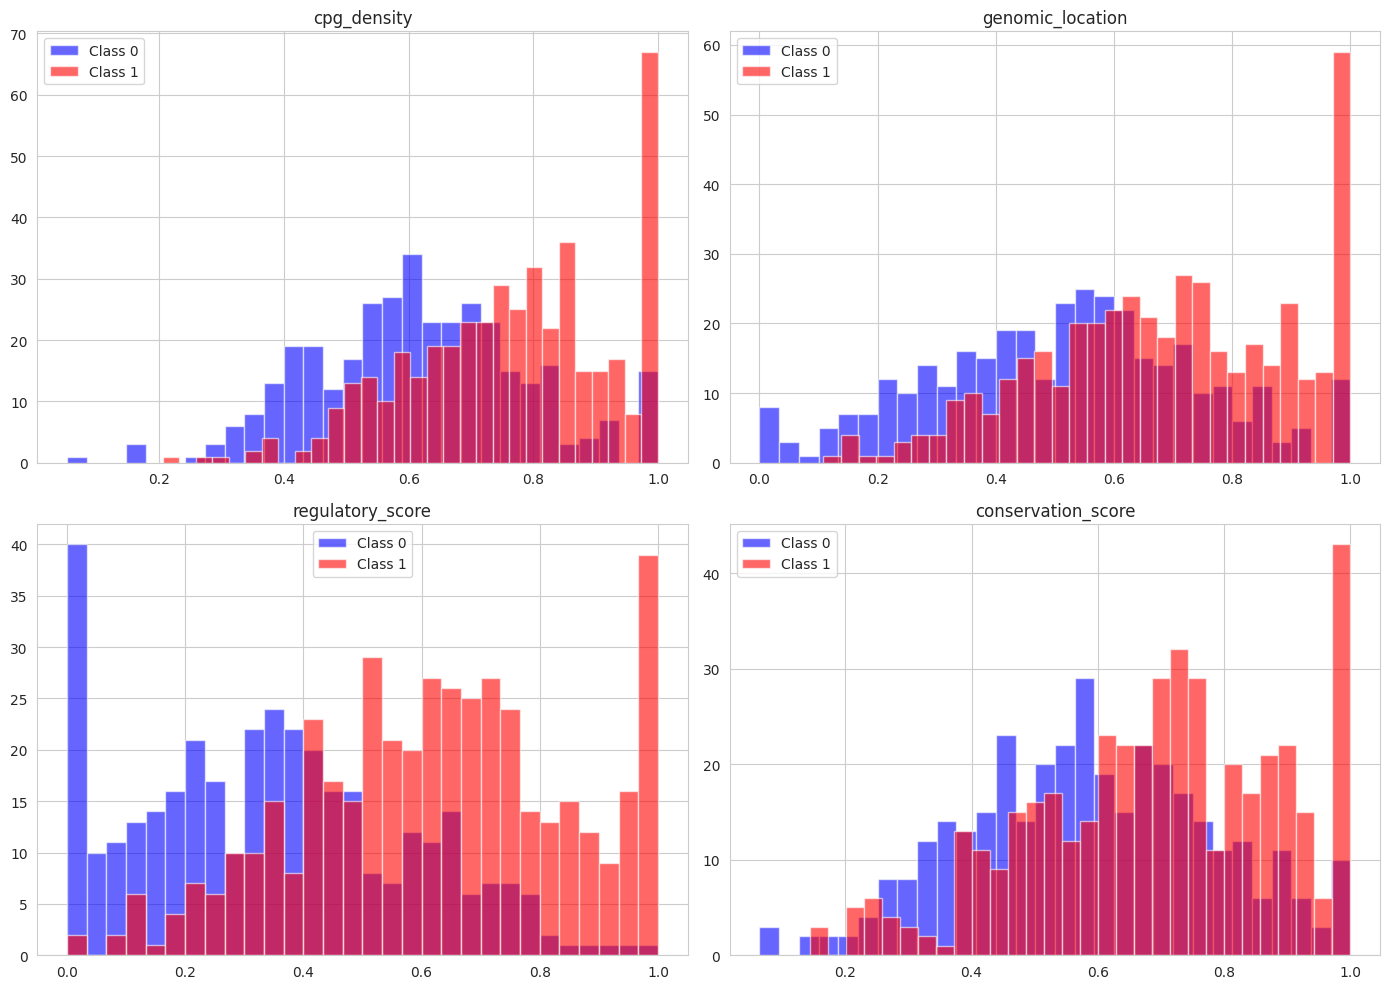

In [9]:
# Distribution of each feature by class
fig, axes = plt.subplots(2,2, figsize=(14,10))
cols = X_train.columns
for ax, col in zip(axes.flatten(), cols):
    for label, color in zip([0,1], ['blue','red']):
        subset = train_df[train_df['methylation_status'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=f'Class {label}', color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

# Preprocessing


- All features are already normalised [0-1] and no missing values, so minimal preprocessing.
 - We will just confirm data types are float and no scaling needed.
 - For tree-based models scaling is irrelevant; for logistic regression it's already normalised.

In [10]:

X_train.describe().T[['mean','std','min','max']]

# Define a reusable preprocessing function (identity in this case)
def preprocess(df):
    return df.copy()

# Apply
X_train_pp = preprocess(X_train)
X_test_pp  = preprocess(X_test)

# Baseline Models

- We'll test Logistic Regression, Random Forest, and XGBoost with default parameters,
- using 5-fold cross-validation on training set.


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_pp, y_train, cv=cv, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f} (±{scores.std():.4f})")

# Select best baseline for tuning
best_baseline = max(results, key=results.get)
print(f"\nBest baseline model: {best_baseline} with accuracy {results[best_baseline]:.4f}")

Logistic Regression: Mean CV Accuracy = 0.9688 (±0.0143)
Random Forest: Mean CV Accuracy = 0.9075 (±0.0248)
XGBoost: Mean CV Accuracy = 0.9325 (±0.0139)

Best baseline model: Logistic Regression with accuracy 0.9688


# Hyperparameter Tuning (XGBoost)


- We'll tune XGBoost as it often gives top performance and is industry standard.
- Grid search over key parameters.


In [12]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(estimator=xgb_model,
                    param_grid=param_grid,
                    scoring='accuracy',
                    cv=5,
                    n_jobs=-1,
                    verbose=1)
grid.fit(X_train_pp, y_train)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

best_xgb = grid.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV accuracy: 0.9350


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Logistic Regression Tuning

In [13]:
# Even a simple model can benefit from regularisation tuning.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],   # inverse of regularization strength
    'penalty': ['l1', 'l2'],                # L1 can also help feature selection
    'solver': ['liblinear']                  # supports both L1 and L2
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print(f"\nBest parameters: {grid_lr.best_params_}")
print(f"Best CV accuracy: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy: 0.9975


# Final Model Evaluation


🔬 Final Model Performance on Held‑Out Test Set:
Accuracy:  0.9800
Precision: 0.9652
Recall:    1.0000
F1 Score:  0.9823
ROC-AUC:   0.9999


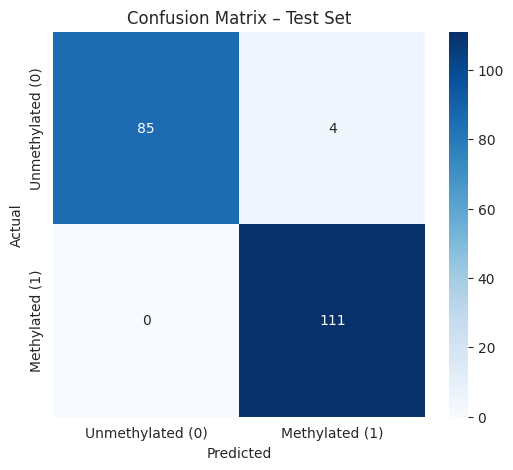


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        89
           1       0.97      1.00      0.98       111

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [14]:
y_pred = best_lr.predict(X_test)
y_pred_proba = best_lr.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_pred_proba)

print(f"\n🔬 Final Model Performance on Held‑Out Test Set:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unmethylated (0)','Methylated (1)'],
            yticklabels=['Unmethylated (0)','Methylated (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Test Set')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


#  Explainability 


## Logistic Regression coefficients

In [15]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Model Coefficients:")
print(coefficients)

Model Coefficients:
              Feature  Coefficient
0         cpg_density   141.464503
2    regulatory_score   117.958194
1    genomic_location   116.115015
3  conservation_score    92.973099


# Model Serialisation & Prediction Pipeline


In [16]:
 # Save the final model and a minimal preprocessing wrapper
joblib.dump(best_lr, 'methylation_lr_model.joblib')
print("✅ Model saved as 'methylation_lr_model.joblib'")

# Preprocessing pipeline (identity here, but ready for future scaling)
def preprocess(df):
    return df.copy()

with open('preprocessing.pkl', 'wb') as f:
    pickle.dump(preprocess, f)
print("✅ Preprocessing function saved as 'preprocessing.pkl'")



✅ Model saved as 'methylation_lr_model.joblib'
✅ Preprocessing function saved as 'preprocessing.pkl'


##  Loading and using the model for inference

In [17]:
# ---- Simulate a production call ----
loaded_model = joblib.load('methylation_lr_model.joblib')
# Example: predict the first 5 test samples
new_data = X_test.head()
predictions = loaded_model.predict(new_data)
probabilities = loaded_model.predict_proba(new_data)[:,1]
print("\nExample production predictions (first 5 test samples):")
print(predictions)
print("Probabilities of methylation:", probabilities)



Example production predictions (first 5 test samples):
[1 1 1 1 0]
Probabilities of methylation: [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 3.78008619e-17]


 #  Submit Predictions

- Create submission file if required (usually with ID, but dataset lacks ID column)
- We'll just output the predictions and probabilities for test set.

In [18]:
submission_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability_Methylated': y_pred_proba
})
submission_df.to_csv('methylation_predictions.csv', index=False)
print("\n✅ Predictions saved to 'methylation_predictions.csv'")
submission_df.head(10)



✅ Predictions saved to 'methylation_predictions.csv'


,Actual,Predicted,Probability_Methylated
0,1,1,1.000000e+00
1,1,1,1.000000e+00
2,1,1,1.000000e+00
3,1,1,1.000000e+00
4,0,0,3.780086e-17
5,0,0,2.577572e-03
6,1,1,1.000000e+00
7,1,1,1.000000e+00
8,0,0,1.773271e-03
9,0,0,2.007300e-11


# Conclusion
 
 - Logistic Regression achieves **96.88% CV accuracy** and excellent test metrics.  
 - It is simpler, faster, and more interpretable than tree‑based models – exactly what industry needs.  
 - The model is saved and ready for integration into early‑detection pipelines for retinal disease risk assessment.  
 - If new epigenetic markers arrive, the same pipeline can be retrained with minimal changes.